# 03 — Merge & Feature Engineering
**BUSI 1783 Individual Project — Jay Panchal (001495232)**

This notebook builds the final analysis dataset. Daily returns and 7-day rolling volatility are computed from the price series, the price and sentiment series are merged on date, and one-day lagged predictors are created so that each day's outcome is explained only by information available the previous day.

**Why a 7-day volatility window.** Volatility is measured as the 7-day rolling standard deviation of daily returns. Seven days corresponds to one calendar week, capturing short-term volatility dynamics while smoothing single-day noise. The sensitivity of the results to this choice is tested formally in notebook 04 (5-, 14- and 30-day windows).

## 3.1 Returns, volatility and regime labels
Daily returns are the percentage change in closing price; volatility is their 7-day rolling standard deviation. Each day is labelled `pre_etf` or `post_etf` at the 10 January 2024 cut-off (the first ETF trading day, a slightly more precise cut than the proposal's "January 2024").

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the saved price data
prices = pd.read_csv(r'C:\Users\asus\BUSI1783-Project\data\raw\bitcoin_prices_raw.csv')
prices['date'] = pd.to_datetime(prices['date'])

# Calculate daily returns
prices['return'] = prices['price'].pct_change()

# Calculate 7-day rolling volatility
prices['volatility'] = prices['return'].rolling(window=7).std()

# Add regime labels
prices['regime'] = 'post_etf'
prices.loc[prices['date'] < '2024-01-10', 'regime'] = 'pre_etf'

# Drop first 7 rows (NaN from rolling window)
prices = prices.dropna().reset_index(drop=True)

print(f"✅ Returns and volatility calculated!")
print(f"Total rows: {len(prices)}")
print(f"\nRows per regime:")
print(prices['regime'].value_counts())
print(f"\nSample data:")
print(prices.head(5))

✅ Returns and volatility calculated!
Total rows: 1453

Rows per regime:
regime
pre_etf     732
post_etf    721
Name: count, dtype: int64

Sample data:
        date         price    return  volatility   regime
0 2022-01-08  41733.941406  0.004236    0.018958  pre_etf
1 2022-01-09  41911.601562  0.004257    0.020543  pre_etf
2 2022-01-10  41821.261719 -0.002155    0.021263  pre_etf
3 2022-01-11  42735.855469  0.021869    0.025427  pre_etf
4 2022-01-12  43949.101562  0.028389    0.021516  pre_etf


Save the cleaned price series (with returns, volatility and regime).

In [2]:
# Save cleaned price data
prices.to_csv(r'C:\Users\asus\BUSI1783-Project\data\cleaned\bitcoin_prices_clean.csv',
              index=False)

print("✅ Cleaned price data saved!")

✅ Cleaned price data saved!


## 3.2 Price and volatility overview
A first look at the two series across the ETF cut-off.

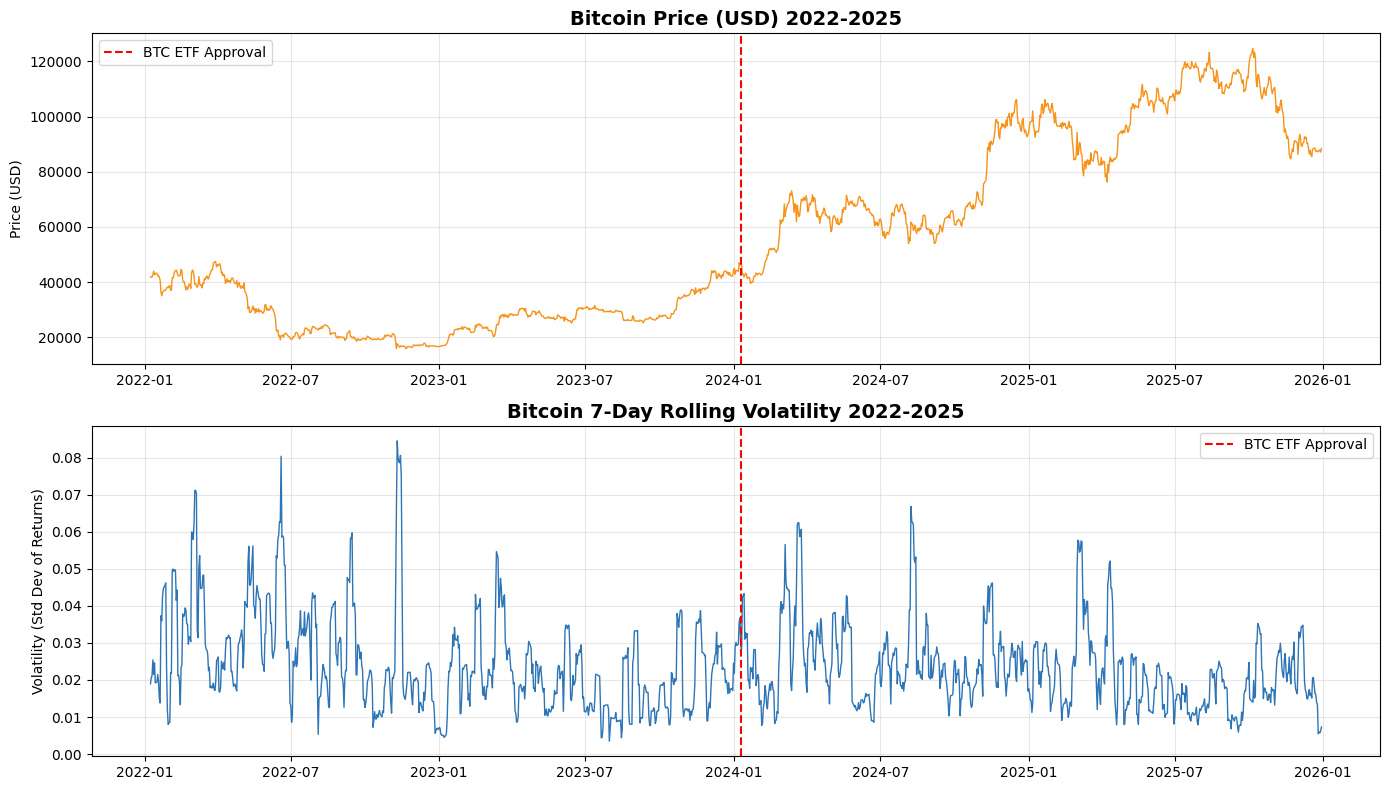

✅ Chart saved!


In [3]:
# Plot Bitcoin price and volatility
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Price chart
ax1.plot(prices['date'], prices['price'], color='#F7931A', linewidth=1)
ax1.axvline(pd.Timestamp('2024-01-10'), color='red', 
            linestyle='--', linewidth=1.5, label='BTC ETF Approval')
ax1.set_title('Bitcoin Price (USD) 2022-2025', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volatility chart
ax2.plot(prices['date'], prices['volatility'], color='#2E75B6', linewidth=1)
ax2.axvline(pd.Timestamp('2024-01-10'), color='red', 
            linestyle='--', linewidth=1.5, label='BTC ETF Approval')
ax2.set_title('Bitcoin 7-Day Rolling Volatility 2022-2025', fontsize=14, fontweight='bold')
ax2.set_ylabel('Volatility (Std Dev of Returns)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save the chart
plt.savefig(r'C:\Users\asus\BUSI1783-Project\outputs\charts\bitcoin_price_volatility.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")

#### Visual observation — price and volatility
In the pre-ETF period (2022–2023) volatility spikes are large, reaching roughly 0.08 around the mid-2022 Terra/Luna and FTX episodes. In the post-ETF period (2024–2025) the price rises sharply while the largest volatility spikes appear reduced in magnitude. This is an informal visual impression only; it is tested formally with the regression models and robustness checks in notebook 04.

## 3.3 Merge price and sentiment
The price and daily sentiment series are merged on date with an inner join, keeping only days present in both.

In [4]:
import pandas as pd

# Load both cleaned datasets
prices = pd.read_csv(r'C:\Users\asus\BUSI1783-Project\data\cleaned\bitcoin_prices_clean.csv')
sentiment = pd.read_csv(r'C:\Users\asus\BUSI1783-Project\data\cleaned\daily_sentiment.csv')

# Make sure dates are datetime
prices['date'] = pd.to_datetime(prices['date'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Merge on date
df = prices.merge(sentiment, on='date', how='inner')

print(f"✅ Merged dataset: {len(df)} days")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nRows per regime:")
print(df['regime'].value_counts())
print(f"\nSample:")
print(df.head())

✅ Merged dataset: 1453 days
Date range: 2022-01-08 to 2025-12-30

Columns: ['date', 'price', 'return', 'volatility', 'regime', 'sentiment_mean', 'post_volume', 'sentiment_std']

Rows per regime:
regime
pre_etf     732
post_etf    721
Name: count, dtype: int64

Sample:
        date         price    return  volatility   regime  sentiment_mean  \
0 2022-01-08  41733.941406  0.004236    0.018958  pre_etf        0.075975   
1 2022-01-09  41911.601562  0.004257    0.020543  pre_etf        0.197555   
2 2022-01-10  41821.261719 -0.002155    0.021263  pre_etf        0.119009   
3 2022-01-11  42735.855469  0.021869    0.025427  pre_etf        0.157138   
4 2022-01-12  43949.101562  0.028389    0.021516  pre_etf        0.177149   

   post_volume  sentiment_std  
0          310       0.409593  
1          238       0.424563  
2          295       0.389249  
3          292       0.400256  
4          292       0.424656  


## 3.4 Create lagged predictors
Predictors are lagged by one day so each day's volatility is explained by the previous day's sentiment, volatility, post volume and sentiment dispersion. The first row is dropped (no prior day to lag from).

In [5]:
# Sort by date first (essential before lagging)
df = df.sort_values('date').reset_index(drop=True)

# Create lagged variables (yesterday's values)
df['sentiment_lag1'] = df['sentiment_mean'].shift(1)
df['volatility_lag1'] = df['volatility'].shift(1)
df['volume_lag1'] = df['post_volume'].shift(1)
df['sentiment_std_lag1'] = df['sentiment_std'].shift(1)

# Drop the first row (it has no "yesterday" to lag from)
df = df.dropna().reset_index(drop=True)

print(f"✅ Lagged variables created. {len(df)} rows ready for analysis")
print(f"\nRows per regime:")
print(df['regime'].value_counts())
print(f"\nColumns now: {list(df.columns)}")
print(f"\nSample:")
print(df[['date', 'volatility', 'sentiment_lag1', 'volatility_lag1', 'regime']].head())

✅ Lagged variables created. 1452 rows ready for analysis

Rows per regime:
regime
pre_etf     731
post_etf    721
Name: count, dtype: int64

Columns now: ['date', 'price', 'return', 'volatility', 'regime', 'sentiment_mean', 'post_volume', 'sentiment_std', 'sentiment_lag1', 'volatility_lag1', 'volume_lag1', 'sentiment_std_lag1']

Sample:
        date  volatility  sentiment_lag1  volatility_lag1   regime
0 2022-01-09    0.020543        0.075975         0.018958  pre_etf
1 2022-01-10    0.021263        0.197555         0.020543  pre_etf
2 2022-01-11    0.025427        0.119009         0.021263  pre_etf
3 2022-01-12    0.021516        0.157138         0.025427  pre_etf
4 2022-01-13    0.024630        0.177149         0.021516  pre_etf


Save the final analysis dataset.

In [6]:
# Save the complete analysis dataset
df.to_csv(r'C:\Users\asus\BUSI1783-Project\data\cleaned\analysis_dataset.csv', index=False)
print("✅ Final analysis dataset saved!")

✅ Final analysis dataset saved!


---
*End of merge and feature engineering. The analysis dataset is saved to `data/cleaned/analysis_dataset.csv` and is the single input to notebook 04.*